# Quantum Genetic Algorithm for Knapsack Problem

In [1]:
#!pip install qiskit qiskit-aer numpy matplotlib tqdm

In [2]:
# Import necessary libraries.
import copy, math, tqdm
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt

# Maximum parameters.
MAX_GEN = 100
MAX_ITEMS = 20

In [3]:
# Compute dot product.
def dot_product(a, b) -> float:
    if len(a) != len(b):
        raise RuntimeError("Dimensions do not match.")

    return np.array(a) @ np.array(b)

# Measure the quantum circuit.
def make(qc) -> list:
    qc.measure_all()

    simulator = Sampler()
    job = simulator.run([qc], shots=1)
    result = job.result()
    counts = result[0].data.meas.get_counts()

    binary = list(counts.keys())[0]
    bin_list = [int(bit) for bit in binary]
    
    return bin_list

# Initializing the circuit with Hadamard gates for superposition.
def initialize(num_items) -> QuantumCircuit:
    qc= QuantumCircuit(num_items)
    for i in range(num_items):
        qc.h(i)
    
    return qc

# Repair the knapsack.
def repair(weights, capacity, binary, num_items) -> list:
    w = weights
    x = [int(bit) for bit in binary]
    i, j = 0, 0

    overfilled = False
    if dot_product(w, x) > capacity:
        overfilled = True

    while overfilled:
        i = np.random.randint(0, num_items)
        x[i] = 0
        if dot_product(w, x) <= capacity:
            overfilled = False

    while not overfilled:
        j = np.random.randint(0, num_items)
        x[j] = 1
        if dot_product(w, x) > capacity:
            overfilled = True

    x[j] = 0

    return x

# Compute profit.
def evaluate(values, binary) -> float:
    return dot_product(values, binary)

# Get rotation angles.
def get_thetas(x, b, fx, fb, num_items) -> list:
    thetas = []
    geq = fx >= fb

    for i in range(num_items):
        if x[i] == 0 and b[i] == 0 and not geq:
            thetas.append(0.0)
        elif x[i] == 0 and b[i] == 0 and geq:
            thetas.append(0.0)
        elif x[i] == 0 and b[i] == 1 and not geq:
            thetas.append(0.0)
        elif x[i] == 0 and b[i] == 1 and geq:
            thetas.append(0.05 * math.pi)
        elif x[i] == 1 and b[i] == 0 and not geq:
            thetas.append(0.01 * math.pi)
        elif x[i] == 1 and b[i] == 0 and geq:
            thetas.append(0.025 * math.pi)
        elif x[i] == 1 and b[i] == 1 and not geq:
            thetas.append(0.005 * math.pi)
        elif x[i] == 1 and b[i] == 1 and geq:
            thetas.append(0.025 * math.pi)
        else:
            raise RuntimeError("There must a typo in one of these if statements.")

    return thetas

# Updating qubit's angle by thetas.
def update(qc, thetas, num_items) -> QuantumCircuit:
    for i in range(num_items):
        qc.ry(thetas[i], i)

    return qc

def gqa(weights, values, capacity, num_items):
    t = 0

    qc_accu = initialize(num_items)
    qc_meas = copy.deepcopy(qc_accu)
    binary = make(qc_meas)
    solution = repair(weights, capacity, binary, num_items)

    profit = evaluate(values, solution)
    
    best_profit = profit
    best_solution = solution
    updates = 1

    while t < MAX_GEN:
        t += 1

        qc_meas = copy.deepcopy(qc_accu)
        binary = make(qc_meas)
        solution = repair(weights, capacity, binary, num_items)

        profit = evaluate(values, solution)
        thetas = get_thetas(solution, best_solution, profit, best_profit, num_items)
        qc_accu = update(qc_accu, thetas, num_items)

        if profit > best_profit:
            best_profit = profit
            best_solution = solution
            updates += 1

    return (best_profit, best_solution, updates)

Running simulations...: 100%|██████████| 19/19 [00:59<00:00,  3.14s/it]


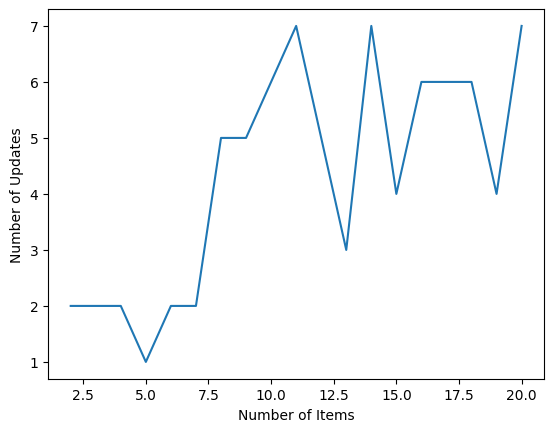

In [4]:
# Problem set up.
weights = np.random.randint(1, 10, MAX_ITEMS)
values = np.random.randint(1, 10, MAX_ITEMS)

# Collect data.
x_data, y_data = [], []
for num_items in tqdm.tqdm(range(2, MAX_ITEMS+1), desc="Running simulations..."):
    curr_weights = weights[:num_items]
    curr_values = values[:num_items]
    capacity = 0.5 * sum(curr_weights)

    (best_profit, best_solution, updates) = gqa(curr_weights, curr_values, capacity, num_items)
    x_data.append(num_items)
    y_data.append(updates)

# Plot data.
plt.plot(x_data, y_data, label='Items vs. Updates')
plt.xlabel("Number of Items")
plt.ylabel("Number of Updates")

plt.show()